# EC1036 - Inteligência Computacional
## Tópico: Decision stump

Após explorarmos o k-NN, vamos dar um passo em direção aos modelos baseados em árvores. O **Decision Stump** é o modelo de classificação mais simples da família das árvores de decisão. 

Se uma árvore de decisão completa é um carvalho cheio de galhos e folhas, o Decision Stump é apenas um "toco": ele tem apenas **um nó de decisão** (uma única pergunta) e **duas folhas** (as respostas).

## O que é um Atributo?

Antes de entender o modelo, precisamos entender nossos dados. Os atributos (parâmetros ou *features*) podem ser:
* **Nominais/Discretos:** Categorias fixas (ex: "É brasileiro?", "Cor do semáforo").
* **Numéricos:** Números reais ou inteiros (ex: "Peso", "Idade", "Comprimento").
* **Strings:** Texto livre (ex: "Nomes").

# 2. Fundamentos do Decision Stump

Um Decision Stump toma uma decisão baseada em **apenas uma característica** do dado de entrada. Ele ignora todas as outras e foca naquela que melhor separa as classes.

**Como ele funciona?**

Para cada atributo, o algoritmo tenta encontrar um "limiar" (*threshold*) que divida os dados da melhor forma possível. 

**Exemplo do Peixe:**
Imagine que temos dados de Comprimento e Peso. O Decision Stump pode criar uma regra simples como:
> **SE** Peso > 1.0 **ENTÃO** Classe A  
> **SENÃO** Classe B

**Funcionalidades Principais:** 

1. **Simplicidade Extrema:** É muito fácil de interpretar (qualquer humano entende a regra).
2. **Baixo Custo Computacional:** Como ele faz apenas uma comparação, é incrivelmente rápido.
3. **Fraco, mas Poderoso:** Sozinho, ele é um "Classificador Fraco" (*Weak Learner*), mas quando combinamos centenas deles (em algoritmos como AdaBoost), eles se tornam extremamente precisos.

## 3. Como o modelo escolhe a "melhor pergunta"?

O desafio do **Decision Stump** é selecionar, entre todos os atributos disponíveis, aquele que melhor separa as classes com **apenas um único corte**. Para isso, o algoritmo considera o tipo de variável e testa divisões possíveis.

**Tipos de atributos e forma de decisão:**

* **Nominais (discretos):** a divisão é feita por categoria  
    *(ex.: `Se Cor == "Vermelho"`)*.
* **Numéricos (contínuos):** o modelo procura um **limiar** (*threshold*)  
    *(ex.: `Se Comprimento > 12.5`)*.
* **Texto (strings):** geralmente precisa ser transformado em categorias ou em indicadores de presença de termos antes do uso.

---

**Critério de seleção:**
O stump avalia múltiplos cortes candidatos para cada atributo e mede o desempenho de cada regra.  
O objetivo é **minimizar a taxa de erro no conjunto de treinamento** (ou, de forma equivalente, maximizar um critério de pureza como Gini/entropia).

*Obs :* um corte pode parecer excelente no treino (ex.: **1 erro**), mas apresentar desempenho pior em dados novos (ex.: **3 erros**).  
Esse contraste destaca a diferença entre **erro de treinamento** e **erro de generalização**.

---

Para avaliar a qualidade das divisões feitas pelo Decision Stump, utilizamos o **índice de Gini**.

O **índice de Gini** é uma métrica que mede o grau de "impureza" de um grupo de dados em relação às classes. Quanto menor o valor do Gini, mais homogêneo é o grupo (ou seja, mais exemplos pertencem à mesma classe). O algoritmo do Decision Stump busca sempre o corte que resulta no menor Gini possível, ou seja, na maior pureza dos grupos formados.

- Se todos os exemplos de um grupo pertencem à mesma classe, o Gini é 0 (grupo totalmente puro).
- Se as classes estão igualmente distribuídas, o Gini é máximo (grupo totalmente impuro).

A fórmula do índice de Gini para um nó é:

$$
Gini = 1 - \sum_{i=1}^{C} p_i^2
$$

Onde $p_i$ é a proporção de exemplos da classe $i$ no nó, e $C$ é o número de classes possíveis.

Durante o treinamento, o Decision Stump testa diferentes divisões e escolhe aquela que gera os grupos mais puros (menor Gini).

## Exemplo

Neste exemplo, vamos usar um pequeno dataset com duas características de peixes (**comprimento** e **peso**) para construir um classificador com **Decision Stump** com profundidade 1.

A ideia é simples: o modelo testa possíveis cortes nesses atributos e escolhe uma única regra que melhor separa as classes. Em termos práticos, ele aprende uma pergunta do tipo:

- **Se atributo $x \leq y$ limiar, então Classe A**
- **Caso contrário, Classe B**

In [77]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
import numpy as np

print(__doc__)

# Colunas: comprimento, peso, classe
data = np.array([
    [12, 3.2, 0],
    [10, 0.5, 1],
    [14, 2.8, 0],
    [14, 2.4, 0],
    [13, 1.8, 1],
    [13.8, 1.5, 0],
    [11, 1, 1]
], dtype=float)

X = data[:, :2]  # duas primeiras colunas são features
y = data[:, 2]   # última coluna é o label

input_dimension = X.shape
if len(input_dimension) != 2:
    raise Exception('Entrada deve ser 2D')
num_features = input_dimension[1]
for k in range(num_features):
    print('característica', k, ', valores e rótulos correspondentes')
    sorted_indices = np.argsort(X[:,k])
    print(X[sorted_indices,k])
    print(y[sorted_indices])

# Abaixo está um exemplo de como usar pesos para cada amostra no conjunto de treinamento
sample_weight = np.ones(y.shape, dtype=float)
# sample_weight[0] = 1000 # neste caso colocamos mais peso na característica_0

# max_depth=1: limita a árvore a apenas 1 nível (raiz + 2 folhas), criando um "stump"
# min_samples_leaf=1: permite que folhas tenham apenas 1 amostra (sem restrição mínima)
# criterion='gini': usa o índice de Gini para medir a qualidade da divisão
decision_stump = DecisionTreeClassifier(max_depth=1, min_samples_leaf=1, criterion='gini')
decision_stump.fit(X, y, sample_weight)

print('\nO decision stump ajustado:')
r = export_text(decision_stump)
print(r)

print('rótulos corretos=',y)
print('   predições=',(decision_stump.predict(X)))


Automatically created module for IPython interactive environment
característica 0 , valores e rótulos correspondentes
[10.  11.  12.  13.  13.8 14.  14. ]
[1. 1. 0. 1. 0. 0. 0.]
característica 1 , valores e rótulos correspondentes
[0.5 1.  1.5 1.8 2.4 2.8 3.2]
[1. 1. 0. 1. 0. 0. 0.]

O decision stump ajustado:
|--- feature_1 <= 2.10
|   |--- class: 1.0
|--- feature_1 >  2.10
|   |--- class: 0.0

rótulos corretos= [0. 1. 0. 0. 1. 0. 1.]
   predições= [0. 1. 0. 0. 1. 1. 1.]


### Visualizando o funcionamento do Decision Stump

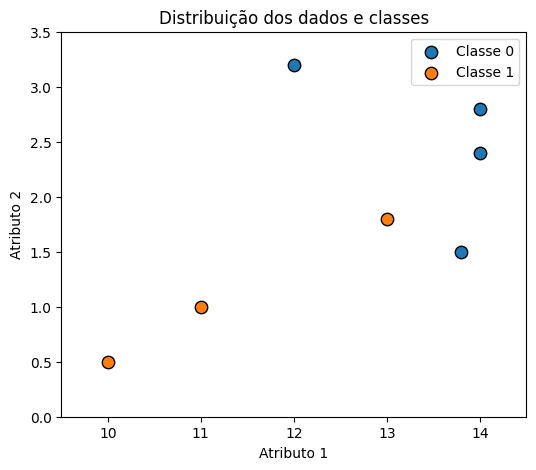

In [92]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# 1. Visualização dos dados e classes (com legenda correta para todas as classes)
plt.figure(figsize=(6, 5))
colors = ListedColormap(['#1f77b4', '#ff7f0e'])
class_labels = np.unique(y)
for class_value in class_labels:
    plt.scatter(X[y==class_value,0], X[y==class_value,1],
                c=[colors(int(class_value))], label=f'Classe {int(class_value)}', edgecolor='k', s=80)
plt.xlim(9.5, 14.5)
plt.ylim(0, 3.5)
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.legend()
plt.title('Distribuição dos dados e classes')
plt.show()

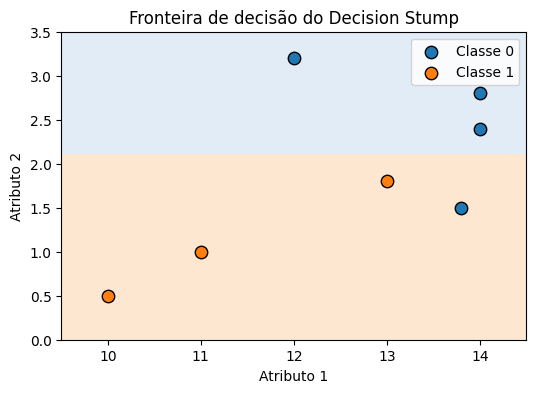

In [94]:
# 2. Visualização da fronteira de decisão do Decision Stump (com legenda correta)

h = .02  # step size in the mesh
# Cria uma grade de pontos no plano e prediz a classe em cada ponto para desenhar a fronteira de decisão
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = decision_stump.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,4))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#c6dbef', '#fdd0a2']), alpha=0.5)
colors = ListedColormap(['#1f77b4', '#ff7f0e'])
class_labels = np.unique(y)
for class_value in class_labels:
    plt.scatter(X[y==class_value, 0], X[y==class_value, 1],
                c=[colors(int(class_value))], label=f'Classe {int(class_value)}', edgecolor='k', s=80)
plt.xlim(9.5, 14.5)
plt.ylim(0, 3.5)
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.legend()
plt.title('Fronteira de decisão do Decision Stump')
plt.show()

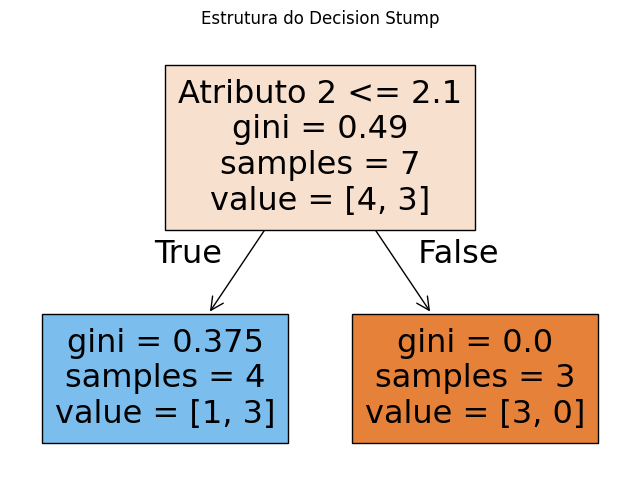

In [95]:
# 3. Visualização da árvore treinada
plt.figure(figsize=(8,6))
plot_tree(decision_stump, filled=True, feature_names=['Atributo 1', 'Atributo 2'])
plt.title('Estrutura do Decision Stump')
plt.show()

#### Como interpretar a árvore acima

- **Nó Raiz (topo da árvore):**
  - **Atributo 2 <= 2.1**: O modelo faz uma única pergunta: o valor do segundo atributo (no seu caso, o “peso” do peixe) é menor ou igual a 2.1?
  - **gini = 0.49**: O índice de Gini mede a impureza dos dados nesse nó. Quanto mais próximo de 0, mais puro (ou seja, mais exemplos de uma única classe).
  - **samples = 7**: Existem 7 exemplos (linhas) no total.
  - **value = [4, 3]**: Desses 7 exemplos, 4 são da classe 0 e 3 da classe 1.

- **Galho Esquerdo (True):**
  - Corresponde aos exemplos onde o atributo 2 é menor ou igual a 2.1.
  - **gini = 0.375**: Impureza dos dados após o corte.
  - **samples = 4**: 4 exemplos caíram nesse grupo.
  - **value = [1, 3]**: 1 exemplo da classe 0 e 3 da classe 1.

- **Galho Direito (False):**
  - Corresponde aos exemplos onde o atributo 2 é maior que 2.1.
  - **gini = 0.0**: Todos os exemplos desse grupo pertencem à mesma classe (puro).
  - **samples = 3**: 3 exemplos nesse grupo.
  - **value = [3, 0]**: Todos são da classe 0.

**Resumo:**
O Decision Stump separa os dados com base no valor do segundo atributo (peso). Se o peso for menor ou igual a 2.1, a maioria dos exemplos é da classe 1; se for maior, todos são da classe 0. O índice de Gini e os valores mostram como os dados ficam divididos após esse corte.